In [7]:
import os
import pandas as pd
import numpy as np

In [8]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_size = {
    "mmlu": 14000,
    "squadv2": 11900,
    "truthful_qa": 817
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuAD2.0",
    "truthful_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
    "gpt-oss-120b": "GPT-OSS-120B",
    "gemma-4-31B-it": "Gemma-4-31B-It.",
    "Qwen3-235B-A22B-Instruct-2507-tput": "Qwen3-235B-Inst."
}

In [9]:
prompt_type = "direct_qa"

In [10]:
def extract_alpha(str):
    # use regex to extract the number after "alpha="
    import re
    match = re.search(r"alpha=([\d.]+),", str)
    if match:        return float(match.group(1))
    else:        return None    

def extract_beta(str):
    # use regex to extract the number after "beta="
    import re
    match = re.search(r"beta=([\d.]+),", str)
    if match:        return float(match.group(1))
    else:        return None   

In [11]:
linguistic_calibration_methods = ["beta_guided", "rewritten"][1]

results_dir = f"/home/ivan/lm-confidence-evaluation-harness/ivny/direct_qa_in_domain_calibration"
if os.path.exists(results_dir):
    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if model_name == "gpt-oss-120b" or model_name.lower() == "qwen3-235b-a22b-instruct-2507-tput":
            continue
        
        # Read calibration_details.csv for alpha/beta values
        details_path = os.path.join(leaf_dir, "calibration_details.csv")
        if not os.path.exists(details_path):
            print(model_name, dataset_name, "missing calibration_details.csv")
            continue
        
        csv_data = pd.read_csv(details_path)
        
        # Extract alpha/beta from the original_lc column
        original_alpha = csv_data["original_lc"].apply(extract_alpha)
        original_beta = csv_data["original_lc"].apply(extract_beta)
        lc_calibrated_alpha = csv_data[f"calibrated_lc_{linguistic_calibration_methods}_lc"].apply(extract_alpha)
        lc_calibrated_beta = csv_data[f"calibrated_lc_{linguistic_calibration_methods}_lc"].apply(extract_beta)
        tp_calibrated_alpha = csv_data[f"calibrated_tp_{linguistic_calibration_methods}_lc"].apply(extract_alpha)
        tp_calibrated_beta = csv_data[f"calibrated_tp_{linguistic_calibration_methods}_lc"].apply(extract_beta)
        su_calibrated_alpha = csv_data[f"calibrated_su_{linguistic_calibration_methods}_lc"].apply(extract_alpha)
        su_calibrated_beta = csv_data[f"calibrated_su_{linguistic_calibration_methods}_lc"].apply(extract_beta)
        accuracy = csv_data["accuracy"].tolist()
        
        # Read precomputed metrics from calibration_performance.csv
        perf_path = os.path.join(leaf_dir, "calibration_performance.csv")
        if not os.path.exists(perf_path):
            print(model_name, dataset_name, "missing calibration_performance.csv")
            continue
        
        perf_data = pd.read_csv(perf_path, index_col=0)
        perf_dict = perf_data['value'].to_dict()

        record = {
            "model_name": model_name_map.get(model_name, model_name),
            "dataset_name": dataset_map.get(dataset_name, dataset_name),
            "original_alpha": original_alpha,
            "original_beta": original_beta,
            "lc_calibrated_alpha": lc_calibrated_alpha,
            "lc_calibrated_beta": lc_calibrated_beta,
            "tp_calibrated_alpha": tp_calibrated_alpha,
            "tp_calibrated_beta": tp_calibrated_beta,
            "su_calibrated_alpha": su_calibrated_alpha,
            "su_calibrated_beta": su_calibrated_beta,
            "accuracy": accuracy,
            "metrics": perf_dict
        }

        all_records.append(record)

else:
    results_dir = "/hdd/ivny/direct_qa_in_domain_calibration"
    # list all leaf nodes in results_dir
    leaf_dirs = []
    for root, dirs, files in os.walk(results_dir):
        if not dirs:  # if there are no subdirectories, it's a leaf node
            leaf_dirs.append(root)

    all_records = []
    for leaf_dir in leaf_dirs:
        _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
        if model_name == "gpt-oss-120b" or model_name.lower() == "qwen3-235b-a22b-instruct-2507-tput":
            continue
        
        # Read calibration_details.csv for alpha/beta values
        details_path = os.path.join(leaf_dir, "calibration_details.csv")
        if not os.path.exists(details_path):
            print(model_name, dataset_name, "missing calibration_details.csv")
            continue
        
        csv_data = pd.read_csv(details_path)
        
        # Extract alpha/beta from the original_lc column
        original_alpha = csv_data["original_lc"].apply(extract_alpha)
        original_beta = csv_data["original_lc"].apply(extract_beta)
        lc_calibrated_alpha = csv_data[f"calibrated_lc_{linguistic_calibration_methods}_lc"].apply(extract_alpha)
        lc_calibrated_beta = csv_data[f"calibrated_lc_{linguistic_calibration_methods}_lc"].apply(extract_beta)
        tp_calibrated_alpha = csv_data[f"calibrated_tp_{linguistic_calibration_methods}_lc"].apply(extract_alpha)
        tp_calibrated_beta = csv_data[f"calibrated_tp_{linguistic_calibration_methods}_lc"].apply(extract_beta)
        su_calibrated_alpha = csv_data[f"calibrated_su_{linguistic_calibration_methods}_lc"].apply(extract_alpha)
        su_calibrated_beta = csv_data[f"calibrated_su_{linguistic_calibration_methods}_lc"].apply(extract_beta)
        accuracy = csv_data["accuracy"].tolist()
        
        # Read precomputed metrics from calibration_performance.csv
        perf_path = os.path.join(leaf_dir, "calibration_performance.csv")
        if not os.path.exists(perf_path):
            print(model_name, dataset_name, "missing calibration_performance.csv")
            continue
        
        perf_data = pd.read_csv(perf_path, index_col=0)
        perf_dict = perf_data['value'].to_dict()

        record = {
            "model_name": model_name_map.get(model_name, model_name),
            "dataset_name": dataset_map.get(dataset_name, dataset_name),
            "original_alpha": original_alpha,
            "original_beta": original_beta,
            "lc_calibrated_alpha": lc_calibrated_alpha,
            "lc_calibrated_beta": lc_calibrated_beta,
            "tp_calibrated_alpha": tp_calibrated_alpha,
            "tp_calibrated_beta": tp_calibrated_beta,
            "su_calibrated_alpha": su_calibrated_alpha,
            "su_calibrated_beta": su_calibrated_beta,
            "accuracy": accuracy,
            "metrics": perf_dict
        }

        all_records.append(record)

figs/in_domain_reliability_diagrams_mmlu.pdf


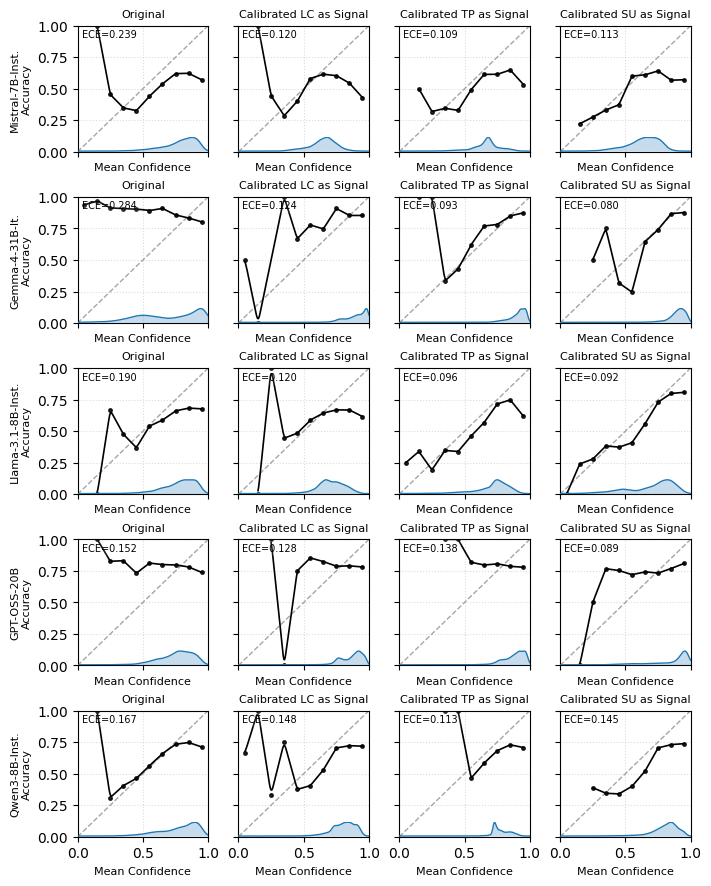

figs/in_domain_reliability_diagrams_squad2.0.pdf


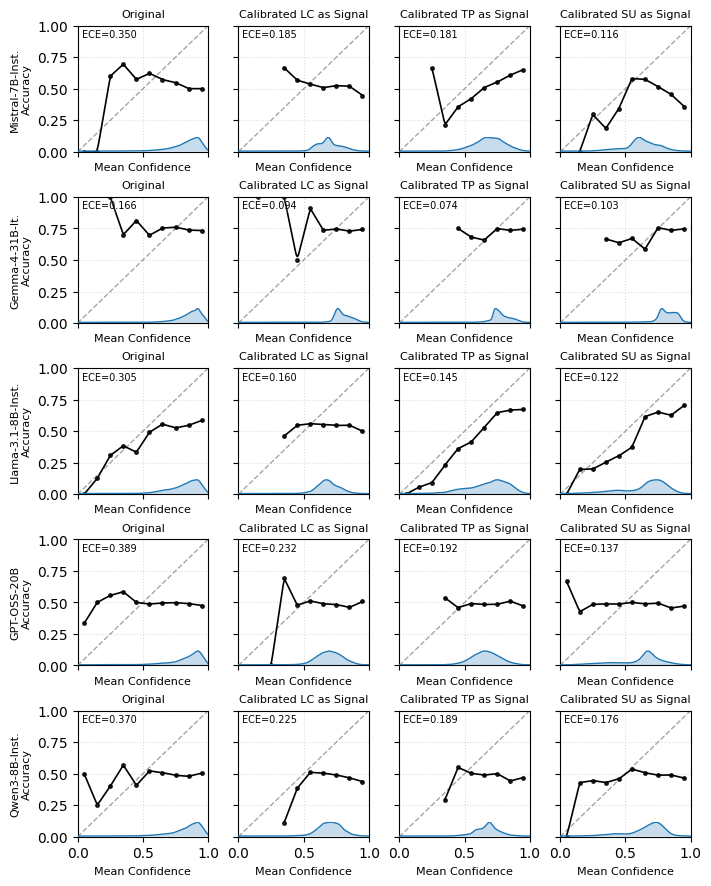

figs/in_domain_reliability_diagrams_truthfulqa.pdf


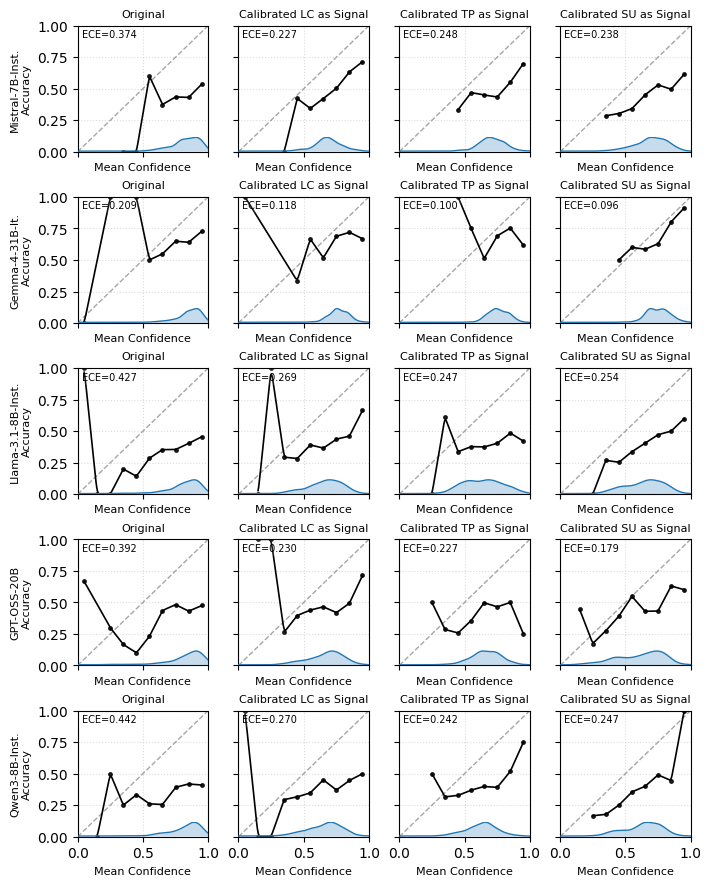

Saved files:


In [12]:
import os
import matplotlib.pyplot as plt
from scipy.special import betaln, psi
from scipy.stats import gaussian_kde


# ---------------------------------------------------------------------------
# Utilities shared across panels
# ---------------------------------------------------------------------------

def _clean_accuracy(values):
    cleaned = []
    for val in values:
        if val is None or (isinstance(val, float) and np.isnan(val)):
            continue
        if val == "":
            val = 0.0
        try:
            cleaned.append(float(val))
        except (ValueError, TypeError):
            continue
    return np.asarray(cleaned, dtype=float)


def _align_and_clean(alpha_vals, beta_vals, accuracy_vals):
    a = np.asarray(alpha_vals, dtype=float)
    b = np.asarray(beta_vals, dtype=float)
    y = np.asarray(accuracy_vals, dtype=float)
    n = min(len(a), len(b), len(y))
    a, b, y = a[:n], b[:n], y[:n]
    mask = np.isfinite(a) & np.isfinite(b) & np.isfinite(y) & (a > 0) & (b > 0)
    return a[mask], b[mask], y[mask]


def _add_density_strip(ax, alpha_vals, beta_vals, color="#1f77b4"):
    a = np.asarray(alpha_vals, dtype=float)
    b = np.asarray(beta_vals, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b) & (a > 0) & (b > 0)
    if mask.sum() < 2:
        return
    mu = a[mask] / (a[mask] + b[mask])
    kde = gaussian_kde(mu, bw_method="scott")
    x_kde = np.linspace(0.0, 1.0, 300)
    density = kde(x_kde)
    ax_ins = ax.inset_axes([0.0, 0.0, 1.0, 0.12])
    ax_ins.plot(x_kde, density, color=color, lw=1.0)
    ax_ins.fill_between(x_kde, density, alpha=0.25, color=color, linewidth=0)
    ax_ins.set_xlim(0, 1)
    ax_ins.axis("off")


def _smooth_curve_fast(x, y, num_points=160, window=9):
    """Efficient smoothing: linear interpolation + Hann-window convolution."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3:
        return x, y

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    dense_x = np.linspace(max(0.0, x.min()), min(1.0, x.max()), num_points)
    dense_y = np.interp(dense_x, x, y)

    if window % 2 == 0:
        window += 1
    window = max(3, min(window, len(dense_y) - (1 - len(dense_y) % 2)))
    if window < 3:
        return dense_x, dense_y

    kernel = np.hanning(window)
    if not np.isfinite(kernel).all() or kernel.sum() <= 0:
        return dense_x, dense_y
    kernel /= kernel.sum()

    pad = window // 2
    y_pad = np.pad(dense_y, (pad, pad), mode="edge")
    smooth_y = np.convolve(y_pad, kernel, mode="valid")
    return dense_x, smooth_y


def _plot_reliability_diagram(ax, alpha_vals, beta_vals, accuracy_vals, panel_title, 
                               precomputed_ece=None, num_bins=10):
    """Fast reliability diagram using equal-width bins + lightweight smoothing.
    
    If precomputed_ece is provided, use it; otherwise compute from data.
    """
    a, b, y = _align_and_clean(alpha_vals, beta_vals, accuracy_vals)
    
    # Use precomputed ECE if available, otherwise compute
    if precomputed_ece is not None:
        ece = precomputed_ece
    else:
        from scipy.special import betaln, psi
        if len(y) == 0:
            ece = np.nan
        else:
            rng = np.random.default_rng(None)
            all_samples = rng.beta(a[:, None], b[:, None], size=(len(y), 200))
            bins = np.linspace(0.0, 1.0, num_bins + 1)
            bin_indices = np.clip(np.digitize(all_samples, bins) - 1, 0, num_bins - 1)
            gece = 0.0
            for m in range(num_bins):
                p_nm = np.mean(bin_indices == m, axis=1)
                pm = p_nm.sum()
                if pm <= 0:
                    continue
                rm = np.sum(p_nm * y) / pm
                gm = all_samples[bin_indices == m].mean() if (bin_indices == m).any() else 0.0
                gece += (pm / len(y)) * abs(rm - gm)
            ece = float(gece)

    ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.7, linewidth=1)

    if len(y) > 0:
        mus = a / (a + b)
        bins = np.linspace(0.0, 1.0, num_bins + 1)
        centers = (bins[:-1] + bins[1:]) / 2.0
        idx = np.clip(np.digitize(mus, bins) - 1, 0, num_bins - 1)

        plot_x = []
        plot_acc = []
        for m in range(num_bins):
            msk = idx == m
            if not np.any(msk):
                continue
            plot_x.append(float(centers[m]))
            plot_acc.append(float(np.mean(y[msk])))

        if len(plot_x) > 0:
            x = np.asarray(plot_x)
            acc = np.asarray(plot_acc)
            sx, sacc = _smooth_curve_fast(x, acc, num_points=160, window=9)
            ax.plot(sx, sacc, "-", color="black", lw=1.2)
            ax.plot(x, acc, "o", color="black", markersize=2.5, alpha=0.85)

    _add_density_strip(ax, alpha_vals, beta_vals)

    ax.text(
        0.03, 0.97,
        f"ECE={ece:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=7,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.1, "pad": 2.0},
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=":", alpha=0.45)
    ax.set_title(panel_title, fontsize=8)


if len(all_records) == 0:
    raise ValueError("No records found. Run the data-loading cell first.")

num_cols = 4
dataset_groups = {}
for rec in all_records:
    dataset_groups.setdefault(rec["dataset_name"], []).append(rec)

saved_paths = []
for dataset_name in sorted(dataset_groups.keys()):
    dataset_records = dataset_groups[dataset_name]
    num_rows = len(dataset_records)

    fig, axes = plt.subplots(
        num_rows, num_cols,
        figsize=(1.75 * num_cols, max(1.75 * num_rows, 3.0)),
        squeeze=False, sharex=True, sharey=True, constrained_layout=True,
    )

    for r, record in enumerate(dataset_records):
        y = _clean_accuracy(record["accuracy"])
        metrics = record["metrics"]
        
        # Extract precomputed ECE values from metrics dictionary
        original_lc_ece = metrics.get("original_lc_generalised_ECE", None)
        lc_calibrated_ece = metrics.get(f"calibrated_lc_{linguistic_calibration_methods}_lc_generalised_ECE", None)
        tp_calibrated_ece = metrics.get(f"calibrated_tp_{linguistic_calibration_methods}_lc_generalised_ECE", None)
        su_calibrated_ece = metrics.get(f"calibrated_su_{linguistic_calibration_methods}_lc_generalised_ECE", None)
        
        panel_data = [
            (record["original_alpha"], record["original_beta"], "Original", original_lc_ece),
            (record["lc_calibrated_alpha"], record["lc_calibrated_beta"], "Calibrated LC as Signal", lc_calibrated_ece),
            (record["tp_calibrated_alpha"], record["tp_calibrated_beta"], "Calibrated TP as Signal", tp_calibrated_ece),
            (record["su_calibrated_alpha"], record["su_calibrated_beta"], "Calibrated SU as Signal", su_calibrated_ece),
        ]
        for c, (a_vals, b_vals, panel_name, precomp_ece) in enumerate(panel_data):
            ax = axes[r, c]
            _plot_reliability_diagram(ax, a_vals, b_vals, y, panel_name, 
                                     precomputed_ece=precomp_ece, num_bins=10)
            if c == 0:
                ax.set_ylabel(f"{record['model_name']}\nAccuracy", fontsize=8)
            ax.set_xlabel("Mean Confidence", fontsize=8)

    safe_name = str(dataset_name).lower().replace(" ", "_").replace("/", "-")
    out_path = f"figs/in_domain_reliability_diagrams_{safe_name}.pdf"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(out_path)
    plt.show()
    plt.close(fig)

print("Saved files:")
for path in saved_paths:
    print(path)